In [ ]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
import pywt
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


In [ ]:
path='/content/drive/MyDrive/models/Binary SQA dataset.csv'

In [ ]:
data=pd.read_csv(path)

In [ ]:
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,4961,4962,4963,4964,4965,4966,4967,4968,4969,4970,4971,4972,4973,4974,4975,4976,4977,4978,4979,4980,4981,4982,4983,4984,4985,4986,4987,4988,4989,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999,Annotation
0,41.000820,19.000380,-18.000360,-9.000180,12.000240,-22.000440,-64.001280,-213.004260,-95.001900,1.000020,13.000260,11.000220,5.000100,7.000140,-11.000220,-14.000280,7.000140,-2.000040,-20.000400,-9.000180,13.000260,27.000540,-6.000120,-23.000460,-13.000260,-5.000100,-4.000080,13.000260,23.000460,-2.000040,-14.000280,-14.000280,30.000600,36.000720,35.000700,-15.000300,-61.001220,-30.000600,149.002980,136.002720,...,9.00018,7.00014,16.00032,20.00040,8.00016,8.00016,-3.00006,-14.00028,-35.00070,-20.00040,-22.00044,-14.00028,26.00052,148.00296,200.00400,28.00056,-49.00098,-23.00046,29.00058,15.00030,-4.00008,-6.00012,-16.00032,-19.00038,-17.00034,-7.00014,-8.00016,-17.00034,-7.00014,-23.00046,-22.00044,-22.00044,2.00004,4.00008,-10.00020,-22.00044,-5.00010,13.00026,25.00050,3.0
1,25.000500,16.000320,0.000000,7.000140,0.000000,-3.000060,-24.000480,-27.000540,-27.000540,-29.000580,-46.000920,-31.000620,-22.000440,-4.000080,31.000620,-96.001920,-411.008220,-216.004320,-116.002320,-16.000320,39.000780,24.000480,0.000000,-39.000780,-14.000280,27.000540,280.005600,171.003420,0.000000,-19.000380,12.000240,-11.000220,-18.000360,19.000380,32.000640,4.000080,-7.000140,-9.000180,-26.000520,-25.000500,...,28.00056,6.00012,7.00014,35.00070,36.00072,25.00050,3.00006,-14.00028,-13.00026,-7.00014,-20.00040,20.00040,37.00074,32.00064,6.00012,2.00004,-22.00044,-30.00060,-18.00036,-1.00002,-13.00026,33.00066,201.00402,111.00222,4.00008,-21.00042,-41.00082,-9.00018,15.00030,2.00004,13.00026,23.00046,-14.00028,-27.00054,-16.00032,3.00006,-10.00020,5.00010,15.00030,3.0
2,65.001300,11.000220,-38.000760,-50.001000,-33.000660,-25.000500,-3.000060,24.000480,-10.000200,-15.000300,-13.000260,-35.000700,-5.000100,15.000300,32.000640,36.000720,27.000540,23.000460,0.000000,-16.000320,-30.000600,-15.000300,-7.000140,-6.000120,2.000040,8.000160,12.000240,0.000000,-36.000720,-180.003600,-222.004440,-66.001320,-38.000760,-14.000280,4.000080,-1.000020,-6.000120,13.000260,26.000520,15.000300,...,-9.00018,16.00032,35.00070,11.00022,-28.00056,-188.00376,-110.00220,23.00046,22.00044,15.00030,-4.00008,-22.00044,-16.00032,-12.00024,-4.00008,21.00042,17.00034,3.00006,-7.00014,-29.00058,-19.00038,14.00028,33.00066,-4.00008,-16.00032,-13.00026,-16.00032,-34.00068,7.00014,34.00068,37.00074,38.00076,20.00040,8.00016,16.00032,24.00048,141.00282,173.00346,62.00124,3.0
3,1415.028301,1433.028661,1435.028701,1418.028361,1430.028601,1447.028941,1446.028921,1428.028561,1422.028441,1420.028401,1426.028521,1426.028521,1415.028301,1408.028161,1417.028341,1443.028861,1461.029221,1464.029281,1465.029301,1461.029221,1456.029121,1449.028981,1442.028841,1444.028881,1451.029021,1457.029141,1449.028981,1444.028881,1450.029001,1452.029041,1435.028701,1443.028861,1464.029281,1484.029681,1488.029761,1477.029541,1468.029361,1459.029181,1447.028941,1438.028761,...,632.01264,638.01276,619.01238,598.01196,608.01216,624.01248,624.01248,630.01260,642.01284,656.01312,641.01282,606.01212,552.01104,497.00994,465.00930,440.00880,423.00846,419.00838,409.00818,371.00742,342.00684,333.00666,338.00676,340.00680,323.00646,297.00594,274.00548,249.00498,239.00478,227.00454,211.00422,200.00400,174.00348,149.00298,129.00258,131.00262,137.00274,125.00250,104.00208,0.0
4,-11.000220,-8.000160,8.000160,-34.000680,-33.000660,-19.000380,3.000060,15.000300,6.000120,-160.003200,-163.003260,-26.000520,-18.000360,-32.000640,-4.000080,6.000120,12.000240,2.000040,-14.000280,8.000160,8.000160,12.000240,12.000240,-18.000360,1.000020,21.000420,8.000160,-8.000160,11.000220,18.000360,4.000080,-4.000080,-1.000020,23.000460,16.000320,9.000180,4.000080,-8.000160,-35.000700,-25.000500,...,-22.00044,-21.00042,6.00012,8.

In [ ]:
y1=data['Annotation']

In [ ]:
y2=data['Annotation'].replace({3.0,1.0}).astype(int)

/tmp/ipython-input-4049325794.py:1: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  y2=data['Annotation'].replace({3.0,1.0}).astype(int)


In [ ]:
y1

,Annotation
0,3.0
1,3.0
2,3.0
3,0.0
4,3.0
...,...
18939,3.0
18940,3.0
18941,0.0
18942,0.0


In [ ]:
data.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,4961,4962,4963,4964,4965,4966,4967,4968,4969,4970,4971,4972,4973,4974,4975,4976,4977,4978,4979,4980,4981,4982,4983,4984,4985,4986,4987,4988,4989,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999,Annotation
count,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,...,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.00000
mean,3.024768,2.452002,1.195612,0.154760,-0.862083,-1.866460,-2.131611,-2.179116,-1.907603,-1.696243,-1.357345,-1.399985,-0.785025,0.182312,0.820756,2.024174,2.393367,2.482085,2.239580,1.597206,1.170798,1.375561,2.029833,2.566924,2.532602,1.842301,1.780718,2.641646,3.221168,2.920899,2.706078,2.476799,3.175461,4.143316,4.808728,5.090381,5.384482,5.496056,5.698561,5.908335,...,1.387363,1.207655,1.340900,1.170906,0.869122,0.747840,0.513265,0.155966,-0.023124,-0.034199,-0.073503,0.117310,0.306514,0.465734,0.726428,1.073904,1.362474,1.481248,1.772785,1.903097,1.616726,1.550417,1.696124,1.759510,1.651913,1.503863,1.368389,1.003650,0.902242,1.018575,0.930666,0.892233,1.001964,1.196882,1.467019,1.709883,1.957210,2.356874,2.901377,1.50000
std,386.218670,388.099238,392.105984,396.322154,398.960569,387.545814,386.297830,393.714040,412.539177,426.463294,427.163005,417.028297,409.598221,406.458007,403.893655,417.966339,426.944067,422.080800,404.450977,396.212617,398.891311,410.559961,423.253302,430.761545,434.667055,417.449353,414.817612,427.079910,447.812128,447.158346,447.074848,447.153368,446.913034,446.759920,446.831766,446.975653,447.299528,447.550574,447.804237,436.963686,...,355.418002,356.011163,357.003558,358.563398,360.216688,362.461255,365.196739,366.664554,366.856834,366.446745,365.669672,364.504955,362.701547,361.509783,361.392003,360.726169,359.851197,359.858008,360.264833,360.717217,361.268153,361.727216,362.816158,363.989117,364.712832,366.443833,368.900653,370.262281,370.953463,371.352880,370.972429,369.300816,365.943339,361.944542,358.185218,354.825875,353.040959,353.570614,355.967218,1.50004
min,-12424.721410,-12403.382597,-12424.721410,-12487.157196,-12495.060460,-12476.092626,-12465.818383,-12431.044021,-12401.801944,-12409.705208,-12419.979452,-12416.027819,-12426.302063,-12438.248765,-12436.248725,-12414.248285,-12391.247825,-12379.247585,-12373.247465,-12367.247345,-12376.247525,-12399.247985,-12411.248225,-12427.248545,-12435.248705,-12444.248885,-12476.249525,-12448.248965,-12433.248665,-12425.248505,-12394.247885,-12382.247645,-12384.247685,-12377.247545,-12385.247705,-12402.248045,-12411.248225,-12425.248505,-12464.249285,-12474.249485,...,-6403.128063,-6371.127423,-6342.126843,-6269.125383,-7089.141783,-8811.176224,-10713.214264,-11680.233605,-11836.236725,-11463.229265,-10842.216844,-10014.200284,-8790.175804,-7582.151643,-6867.137343,-6005.120102,-6037.120742,-6038.120762,-6025.120502,-6064.121282,-6126.122522,-6945.138903,-8473.169463,-9999.199984,-11007.220144,-12281.245625,-13583.271665,-13883.277666,-13500.270005,-12792.255845,-11933.238665,-10860.217204,-9315.1

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5486 entries, 0 to 5485
Columns: 5001 entries, 0 to Annotation
dtypes: float64(5001)
memory usage: 209.3 MB


In [ ]:
data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,4960,4961,4962,4963,4964,4965,4966,4967,4968,4969,4970,4971,4972,4973,4974,4975,4976,4977,4978,4979,4980,4981,4982,4983,4984,4985,4986,4987,4988,4989,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,41.000820,19.000380,-18.000360,-9.000180,12.000240,-22.000440,-64.001280,-213.004260,-95.001900,1.000020,13.000260,11.000220,5.000100,7.000140,-11.000220,-14.000280,7.000140,-2.000040,-20.000400,-9.000180,13.000260,27.000540,-6.000120,-23.000460,-13.000260,-5.000100,-4.000080,13.000260,23.000460,-2.000040,-14.000280,-14.000280,30.000600,36.000720,35.000700,-15.000300,-61.001220,-30.000600,149.002980,136.002720,...,12.00024,9.00018,7.00014,16.00032,20.00040,8.00016,8.00016,-3.00006,-14.00028,-35.00070,-20.00040,-22.00044,-14.00028,26.00052,148.00296,200.00400,28.00056,-49.00098,-23.00046,29.00058,15.00030,-4.00008,-6.00012,-16.00032,-19.00038,-17.00034,-7.00014,-8.00016,-17.00034,-7.00014,-23.00046,-22.00044,-22.00044,2.00004,4.00008,-10.00020,-22.00044,-5.00010,13.00026,25.00050
1,25.000500,16.000320,0.000000,7.000140,0.000000,-3.000060,-24.000480,-27.000540,-27.000540,-29.000580,-46.000920,-31.000620,-22.000440,-4.000080,31.000620,-96.001920,-411.008220,-216.004320,-116.002320,-16.000320,39.000780,24.000480,0.000000,-39.000780,-14.000280,27.000540,280.005600,171.003420,0.000000,-19.000380,12.000240,-11.000220,-18.000360,19.000380,32.000640,4.000080,-7.000140,-9.000180,-26.000520,-25.000500,...,54.00108,28.00056,6.00012,7.00014,35.00070,36.00072,25.00050,3.00006,-14.00028,-13.00026,-7.00014,-20.00040,20.00040,37.00074,32.00064,6.00012,2.00004,-22.00044,-30.00060,-18.00036,-1.00002,-13.00026,33.00066,201.00402,111.00222,4.00008,-21.00042,-41.00082,-9.00018,15.00030,2.00004,13.00026,23.00046,-14.00028,-27.00054,-16.00032,3.00006,-10.00020,5.00010,15.00030
2,65.001300,11.000220,-38.000760,-50.001000,-33.000660,-25.000500,-3.000060,24.000480,-10.000200,-15.000300,-13.000260,-35.000700,-5.000100,15.000300,32.000640,36.000720,27.000540,23.000460,0.000000,-16.000320,-30.000600,-15.000300,-7.000140,-6.000120,2.000040,8.000160,12.000240,0.000000,-36.000720,-180.003600,-222.004440,-66.001320,-38.000760,-14.000280,4.000080,-1.000020,-6.000120,13.000260,26.000520,15.000300,...,6.00012,-9.00018,16.00032,35.00070,11.00022,-28.00056,-188.00376,-110.00220,23.00046,22.00044,15.00030,-4.00008,-22.00044,-16.00032,-12.00024,-4.00008,21.00042,17.00034,3.00006,-7.00014,-29.00058,-19.00038,14.00028,33.00066,-4.00008,-16.00032,-13.00026,-16.00032,-34.00068,7.00014,34.00068,37.00074,38.00076,20.00040,8.00016,16.00032,24.00048,141.00282,173.00346,62.00124
3,1415.028301,1433.028661,1435.028701,1418.028361,1430.028601,1447.028941,1446.028921,1428.028561,1422.028441,1420.028401,1426.028521,1426.028521,1415.028301,1408.028161,1417.028341,1443.028861,1461.029221,1464.029281,1465.029301,1461.029221,1456.029121,1449.028981,1442.028841,1444.028881,1451.029021,1457.029141,1449.028981,1444.028881,1450.029001,1452.029041,1435.028701,1443.028861,1464.029281,1484.029681,1488.029761,1477.029541,1468.029361,1459.029181,1447.028941,1438.028761,...,624.01248,632.01264,638.01276,619.01238,598.01196,608.01216,624.01248,624.01248,630.01260,642.01284,656.01312,641.01282,606.01212,552.01104,497.00994,465.00930,440.00880,423.00846,419.00838,409.00818,371.00742,342.00684,333.00666,338.00676,340.00680,323.00646,297.00594,274.00548,249.00498,239.00478,227.00454,211.00422,200.00400,174.00348,149.00298,129.00258,131.00262,137.00274,125.00250,104.00208
4,-11.000220,-8.000160,8.000160,-34.000680,-33.000660,-19.000380,3.000060,15.000300,6.000120,-160.003200,-163.003260,-26.000520,-18.000360,-32.000640,-4.000080,6.000120,12.000240,2.000040,-14.000280,8.000160,8.000160,12.000240,12.000240,-18.000360,1.000020,21.000420,8.000160,-8.000160,11.000220,18.000360,4.000080,-4.000080,-1.000020,23.000460,16.000320,9.000180,4.000080,-8.000160,-35.000700,-25.000500,...,-20.00040,-22.00

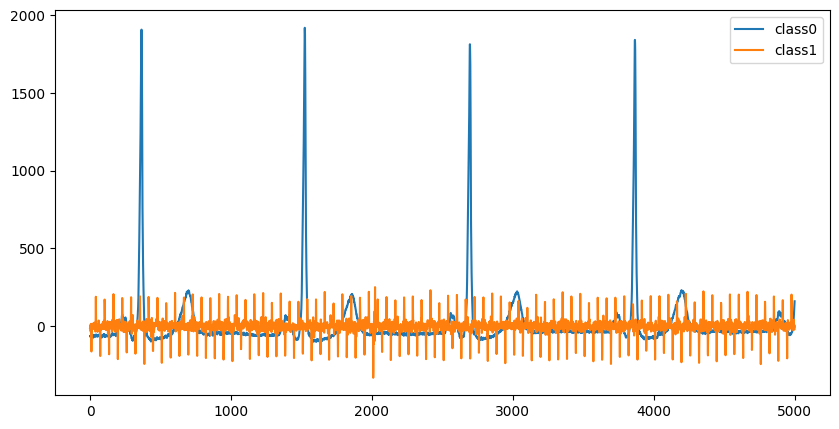

In [ ]:
feature_cols=data.columns.drop('Annotation')
sample_1=data.loc[data['Annotation']==0.0,feature_cols].iloc[3].values
sample_2=data.loc[data['Annotation']==3.0,feature_cols].iloc[3].values

plt.figure(figsize=(10,5))
plt.plot(sample_1,label='class0')
plt.plot(sample_2,label='class1')
plt.legend()
plt.show()

In [ ]:
data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,4961,4962,4963,4964,4965,4966,4967,4968,4969,4970,4971,4972,4973,4974,4975,4976,4977,4978,4979,4980,4981,4982,4983,4984,4985,4986,4987,4988,4989,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999,Annotation
0,41.000820,19.000380,-18.000360,-9.000180,12.000240,-22.000440,-64.001280,-213.004260,-95.001900,1.000020,13.000260,11.000220,5.000100,7.000140,-11.000220,-14.000280,7.000140,-2.000040,-20.000400,-9.000180,13.000260,27.000540,-6.000120,-23.000460,-13.000260,-5.000100,-4.000080,13.000260,23.000460,-2.000040,-14.000280,-14.000280,30.000600,36.000720,35.000700,-15.000300,-61.001220,-30.000600,149.002980,136.002720,...,9.00018,7.00014,16.00032,20.00040,8.00016,8.00016,-3.00006,-14.00028,-35.00070,-20.00040,-22.00044,-14.00028,26.00052,148.00296,200.00400,28.00056,-49.00098,-23.00046,29.00058,15.00030,-4.00008,-6.00012,-16.00032,-19.00038,-17.00034,-7.00014,-8.00016,-17.00034,-7.00014,-23.00046,-22.00044,-22.00044,2.00004,4.00008,-10.00020,-22.00044,-5.00010,13.00026,25.00050,3.0
1,25.000500,16.000320,0.000000,7.000140,0.000000,-3.000060,-24.000480,-27.000540,-27.000540,-29.000580,-46.000920,-31.000620,-22.000440,-4.000080,31.000620,-96.001920,-411.008220,-216.004320,-116.002320,-16.000320,39.000780,24.000480,0.000000,-39.000780,-14.000280,27.000540,280.005600,171.003420,0.000000,-19.000380,12.000240,-11.000220,-18.000360,19.000380,32.000640,4.000080,-7.000140,-9.000180,-26.000520,-25.000500,...,28.00056,6.00012,7.00014,35.00070,36.00072,25.00050,3.00006,-14.00028,-13.00026,-7.00014,-20.00040,20.00040,37.00074,32.00064,6.00012,2.00004,-22.00044,-30.00060,-18.00036,-1.00002,-13.00026,33.00066,201.00402,111.00222,4.00008,-21.00042,-41.00082,-9.00018,15.00030,2.00004,13.00026,23.00046,-14.00028,-27.00054,-16.00032,3.00006,-10.00020,5.00010,15.00030,3.0
2,65.001300,11.000220,-38.000760,-50.001000,-33.000660,-25.000500,-3.000060,24.000480,-10.000200,-15.000300,-13.000260,-35.000700,-5.000100,15.000300,32.000640,36.000720,27.000540,23.000460,0.000000,-16.000320,-30.000600,-15.000300,-7.000140,-6.000120,2.000040,8.000160,12.000240,0.000000,-36.000720,-180.003600,-222.004440,-66.001320,-38.000760,-14.000280,4.000080,-1.000020,-6.000120,13.000260,26.000520,15.000300,...,-9.00018,16.00032,35.00070,11.00022,-28.00056,-188.00376,-110.00220,23.00046,22.00044,15.00030,-4.00008,-22.00044,-16.00032,-12.00024,-4.00008,21.00042,17.00034,3.00006,-7.00014,-29.00058,-19.00038,14.00028,33.00066,-4.00008,-16.00032,-13.00026,-16.00032,-34.00068,7.00014,34.00068,37.00074,38.00076,20.00040,8.00016,16.00032,24.00048,141.00282,173.00346,62.00124,3.0
3,1415.028301,1433.028661,1435.028701,1418.028361,1430.028601,1447.028941,1446.028921,1428.028561,1422.028441,1420.028401,1426.028521,1426.028521,1415.028301,1408.028161,1417.028341,1443.028861,1461.029221,1464.029281,1465.029301,1461.029221,1456.029121,1449.028981,1442.028841,1444.028881,1451.029021,1457.029141,1449.028981,1444.028881,1450.029001,1452.029041,1435.028701,1443.028861,1464.029281,1484.029681,1488.029761,1477.029541,1468.029361,1459.029181,1447.028941,1438.028761,...,632.01264,638.01276,619.01238,598.01196,608.01216,624.01248,624.01248,630.01260,642.01284,656.01312,641.01282,606.01212,552.01104,497.00994,465.00930,440.00880,423.00846,419.00838,409.00818,371.00742,342.00684,333.00666,338.00676,340.00680,323.00646,297.00594,274.00548,249.00498,239.00478,227.00454,211.00422,200.00400,174.00348,149.00298,129.00258,131.00262,137.00274,125.00250,104.00208,0.0
4,-11.000220,-8.000160,8.000160,-34.000680,-33.000660,-19.000380,3.000060,15.000300,6.000120,-160.003200,-163.003260,-26.000520,-18.000360,-32.000640,-4.000080,6.000120,12.000240,2.000040,-14.000280,8.000160,8.000160,12.000240,12.000240,-18.000360,1.000020,21.000420,8.000160,-8.000160,11.000220,18.000360,4.000080,-4.000080,-1.000020,23.000460,16.000320,9.000180,4.000080,-8.000160,-35.000700,-25.000500,...,-22.00044,-21.00042,6.00012,8.

In [ ]:
counts_series = data['Annotation'].value_counts()
y = counts_series.index
x = counts_series.values

In [ ]:
data.drop(['Annotation'],axis=1,inplace=True)

In [ ]:
data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,4960,4961,4962,4963,4964,4965,4966,4967,4968,4969,4970,4971,4972,4973,4974,4975,4976,4977,4978,4979,4980,4981,4982,4983,4984,4985,4986,4987,4988,4989,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,41.000820,19.000380,-18.000360,-9.000180,12.000240,-22.000440,-64.001280,-213.004260,-95.001900,1.000020,13.000260,11.000220,5.000100,7.000140,-11.000220,-14.000280,7.000140,-2.000040,-20.000400,-9.000180,13.000260,27.000540,-6.000120,-23.000460,-13.000260,-5.000100,-4.000080,13.000260,23.000460,-2.000040,-14.000280,-14.000280,30.000600,36.000720,35.000700,-15.000300,-61.001220,-30.000600,149.002980,136.002720,...,12.00024,9.00018,7.00014,16.00032,20.00040,8.00016,8.00016,-3.00006,-14.00028,-35.00070,-20.00040,-22.00044,-14.00028,26.00052,148.00296,200.00400,28.00056,-49.00098,-23.00046,29.00058,15.00030,-4.00008,-6.00012,-16.00032,-19.00038,-17.00034,-7.00014,-8.00016,-17.00034,-7.00014,-23.00046,-22.00044,-22.00044,2.00004,4.00008,-10.00020,-22.00044,-5.00010,13.00026,25.00050
1,25.000500,16.000320,0.000000,7.000140,0.000000,-3.000060,-24.000480,-27.000540,-27.000540,-29.000580,-46.000920,-31.000620,-22.000440,-4.000080,31.000620,-96.001920,-411.008220,-216.004320,-116.002320,-16.000320,39.000780,24.000480,0.000000,-39.000780,-14.000280,27.000540,280.005600,171.003420,0.000000,-19.000380,12.000240,-11.000220,-18.000360,19.000380,32.000640,4.000080,-7.000140,-9.000180,-26.000520,-25.000500,...,54.00108,28.00056,6.00012,7.00014,35.00070,36.00072,25.00050,3.00006,-14.00028,-13.00026,-7.00014,-20.00040,20.00040,37.00074,32.00064,6.00012,2.00004,-22.00044,-30.00060,-18.00036,-1.00002,-13.00026,33.00066,201.00402,111.00222,4.00008,-21.00042,-41.00082,-9.00018,15.00030,2.00004,13.00026,23.00046,-14.00028,-27.00054,-16.00032,3.00006,-10.00020,5.00010,15.00030
2,65.001300,11.000220,-38.000760,-50.001000,-33.000660,-25.000500,-3.000060,24.000480,-10.000200,-15.000300,-13.000260,-35.000700,-5.000100,15.000300,32.000640,36.000720,27.000540,23.000460,0.000000,-16.000320,-30.000600,-15.000300,-7.000140,-6.000120,2.000040,8.000160,12.000240,0.000000,-36.000720,-180.003600,-222.004440,-66.001320,-38.000760,-14.000280,4.000080,-1.000020,-6.000120,13.000260,26.000520,15.000300,...,6.00012,-9.00018,16.00032,35.00070,11.00022,-28.00056,-188.00376,-110.00220,23.00046,22.00044,15.00030,-4.00008,-22.00044,-16.00032,-12.00024,-4.00008,21.00042,17.00034,3.00006,-7.00014,-29.00058,-19.00038,14.00028,33.00066,-4.00008,-16.00032,-13.00026,-16.00032,-34.00068,7.00014,34.00068,37.00074,38.00076,20.00040,8.00016,16.00032,24.00048,141.00282,173.00346,62.00124
3,1415.028301,1433.028661,1435.028701,1418.028361,1430.028601,1447.028941,1446.028921,1428.028561,1422.028441,1420.028401,1426.028521,1426.028521,1415.028301,1408.028161,1417.028341,1443.028861,1461.029221,1464.029281,1465.029301,1461.029221,1456.029121,1449.028981,1442.028841,1444.028881,1451.029021,1457.029141,1449.028981,1444.028881,1450.029001,1452.029041,1435.028701,1443.028861,1464.029281,1484.029681,1488.029761,1477.029541,1468.029361,1459.029181,1447.028941,1438.028761,...,624.01248,632.01264,638.01276,619.01238,598.01196,608.01216,624.01248,624.01248,630.01260,642.01284,656.01312,641.01282,606.01212,552.01104,497.00994,465.00930,440.00880,423.00846,419.00838,409.00818,371.00742,342.00684,333.00666,338.00676,340.00680,323.00646,297.00594,274.00548,249.00498,239.00478,227.00454,211.00422,200.00400,174.00348,149.00298,129.00258,131.00262,137.00274,125.00250,104.00208
4,-11.000220,-8.000160,8.000160,-34.000680,-33.000660,-19.000380,3.000060,15.000300,6.000120,-160.003200,-163.003260,-26.000520,-18.000360,-32.000640,-4.000080,6.000120,12.000240,2.000040,-14.000280,8.000160,8.000160,12.000240,12.000240,-18.000360,1.000020,21.000420,8.000160,-8.000160,11.000220,18.000360,4.000080,-4.000080,-1.000020,23.000460,16.000320,9.000180,4.000080,-8.000160,-35.000700,-25.000500,...,-20.00040,-22.00

In [ ]:
y

Index([3.0, 0.0], dtype='float64', name='Annotation')

In [ ]:
x

array([9472, 9472])

In [ ]:
wavlet_component = pywt.wavedec(data.iloc[0:1,:].values, 'db6', level=8)

In [ ]:
len(wavlet_component)

9

In [ ]:
wavlet_component[8].shape


(1, 2505)

In [ ]:
def dwt(signal,level=8):
  wavlet_component = pywt.wavedec(signal, 'db6', level=8)
  dwt_features=[]
  for i in range(len(wavlet_component)):
    total_energy=np.sum(wavlet_component[i]**2)
    for j in range(len(wavlet_component[i])):
      if(wavlet_component[i][j]**2>0.1*total_energy):
        dwt_features.append(wavlet_component[i][j])
  return dwt_features

In [ ]:
dwt_features=[]
for i in range(len(data)):
  dwt_features.append(dwt(data.iloc[i]))

In [ ]:
ms=MinMaxScaler()

In [ ]:
dwt_features_df = pd.DataFrame(dwt_features)
dwt_features_filled = dwt_features_df.fillna(0)
dwt_scaled = ms.fit_transform(dwt_features_filled)

In [ ]:
dwt_features

[[np.float64(-507.79468317426176),
  np.float64(-528.707766457082),
  np.float64(-525.5951452513413),
  np.float64(-536.8621916128146),
  np.float64(-506.0970528139117),
  np.float64(-540.3657681886147),
  np.float64(-517.6359460282722),
  np.float64(-543.2219601572829),
  np.float64(-532.1273421080514),
  np.float64(-113.12235258169311),
  np.float64(-57.9082510231194),
  np.float64(-53.529001742210035)],
 [np.float64(-85.72856022204668),
  np.float64(84.1378295403298),
  np.float64(-51.27075701112236),
  np.float64(-36.65731635066827)],
 [np.float64(577.856807505094),
  np.float64(358.2003940655215),
  np.float64(138.6868239696808),
  np.float64(-170.64815561778377),
  np.float64(98.61261231377301),
  np.float64(202.1574242662459)],
 [np.float64(11249.663403056069),
  np.float64(13748.424634640185),
  np.float64(7372.494514231451),
  np.float64(7963.7054867456245),
  np.float64(-4736.110720274225),
  np.float64(5639.775205251887),
  np.float64(-4403.630618353404),
  np.float64(4659.6

In [ ]:
ms=MinMaxScaler()

In [ ]:
dwt_feature=pd.DataFrame(dwt_features)

In [ ]:
dwt_feature

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
0,-507.794683,-528.707766,-525.595145,-536.862192,-506.097053,-540.365768,-517.635946,-543.221960,-532.127342,-113.122353,-57.908251,-53.529002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-85.728560,84.137830,-51.270757,-36.657316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,577.856808,358.200394,138.686824,-170.648156,98.612612,202.157424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11249.663403,13748.424635,7372.494514,7963.705487,-4736.110720,5639.775205,-4403.630618,4659.608483,-3144.034525,2722.788347,-847.772290,-484.275944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-209.991709,-220.590872,-220.359611,-220.754530,-211.749380,-220.030027,-220.946117,-221.571558,-223.584831,51.514780,37.493962,-59.854627,-66.611166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18939,-177.922483,-92.357099,58.828848,-55.719893,59.370983,-53.345578,-61.533008,-61.205517,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18940,-457.207440,-482.629042,-479.405476,-487.810851,-454.418926,-489.441886,-472.923469,-498.542824,-471.879952,-106.232126,63.127427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18941,-147.750967,-131.735866,111.388080,110.109346,-122.133340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18942,-30744.790357,-26478.521338,-16038.015524,6823.285876,-5893.309127,-6871.296105,7827.582821,4079.034645,-3498.736057,-3961.129032,3418.432886,-3008.183284,-3373.779707,-3498.500993,-2990.346058,2671.330517,-1415.181597,-989.678104,273.197376,-281.885805,133.796351,-153.489458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dwt_feature.fillna(0)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
0,-507.794683,-528.707766,-525.595145,-536.862192,-506.097053,-540.365768,-517.635946,-543.221960,-532.127342,-113.122353,-57.908251,-53.529002,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-85.728560,84.137830,-51.270757,-36.657316,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,577.856808,358.200394,138.686824,-170.648156,98.612612,202.157424,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,11249.663403,13748.424635,7372.494514,7963.705487,-4736.110720,5639.775205,-4403.630618,4659.608483,-3144.034525,2722.788347,-847.772290,-484.275944,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-209.991709,-220.590872,-220.359611,-220.754530,-211.749380,-220.030027,-220.946117,-221.571558,-223.584831,51.514780,37.493962,-59.854627,-66.611166,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18939,-177.922483,-92.357099,58.828848,-55.719893,59.370983,-53.345578,-61.533008,-61.205517,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18940,-457.207440,-482.629042,-479.405476,-487.810851,-454.418926,-489.441886,-472.923469,-498.542824,-471.879952,-106.232126,63.127427,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18941,-147.750967,-131.735866,111.388080,110.109346,-122.133340,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18942,-30744.790357,-26478.521338,-16038.015524,6823.285876,-5893.309127,-6871.296105,7827.582821,4079.034645,-3498.736057,-3961.129032,3418.432886,-3008.183284,-3373.779707,-3498.500993,-2990.346058,2671.330517,-1415.181597,-989.678104,273.197376,-281.885805,133.796351,-153.489458,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
dwt_scaled

array([[0.32581786, 0.3929051 , 0.33053466, ..., 0.2361605 , 0.38801428,
        0.58830464],
       [0.3267065 , 0.39446086, 0.33193206, ..., 0.2361605 , 0.38801428,
        0.58830464],
       [0.32956752, 0.39624304, 0.33305311, ..., 0.2361605 , 0.38801428,
        0.58830464],
       ...,
       [0.32634344, 0.3954048 , 0.33164783, ..., 0.2361605 , 0.38801428,
        0.58830464],
       [0.26215501, 0.32845107, 0.28088929, ..., 0.2361605 , 0.38801428,
        0.58830464],
       [0.32617374, 0.39369798, 0.3323095 , ..., 0.2361605 , 0.38801428,
        0.58830464]])

In [ ]:
new_data=pd.DataFrame(dwt_scaled)

In [ ]:
new_data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32
0,0.325818,0.392905,0.330535,0.351642,0.496600,0.229809,0.782858,0.705303,0.353772,0.367190,0.449784,0.569842,0.313095,0.398071,0.495970,0.329089,0.415570,0.310549,0.646096,0.731332,0.38838,0.445528,0.56842,0.623759,0.468667,0.269535,0.23908,0.836239,0.685279,0.557228,0.236161,0.388014,0.588305
1,0.326707,0.394461,0.331932,0.353501,0.498977,0.231823,0.784706,0.708239,0.356394,0.368104,0.450265,0.570299,0.313095,0.398071,0.495970,0.329089,0.415570,0.310549,0.646096,0.731332,0.38838,0.445528,0.56842,0.623759,0.468667,0.269535,0.23908,0.836239,0.685279,0.557228,0.236161,0.388014,0.588305
2,0.329568,0.396243,0.333053,0.352157,0.499897,0.231046,0.786199,0.708239,0.356394,0.368104,0.450265,0.570299,0.313095,0.398071,0.495970,0.329089,0.415570,0.310549,0.646096,0.731332,0.38838,0.445528,0.56842,0.623759,0.468667,0.269535,0.23908,0.836239,0.685279,0.557228,0.236161,0.388014,0.588305
3,0.350973,0.429214,0.353803,0.383178,0.476732,0.252856,0.768952,0.733423,0.340905,0.390107,0.443221,0.566164,0.313095,0.398071,0.495970,0.329089,0.415570,0.310549,0.646096,0.731332,0.38838,0.445528,0.56842,0.623759,0.468667,0.269535,0.23908,0.836239,0.685279,0.557228,0.236161,0.388014,0.588305
4,0.326423,0.393692,0.331433,0.352819,0.497939,0.230997,0.783908,0.708518,0.356178,0.368525,0.449768,0.569477,0.313095,0.398071,0.495970,0.329089,0.415570,0.310549,0.646096,0.731332,0.38838,0.445528,0.56842,0.623759,0.468667,0.269535,0.23908,0.836239,0.685279,0.557228,0.236161,0.388014,0.588305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18939,0.326282,0.393850,0.331831,0.353990,0.498688,0.231468,0.784706,0.708239,0.356394,0.368104,0.450265,0.570299,0.313095,0.398071,0.495970,0.329089,0.415570,0.310549,0.646096,0.731332,0.38838,0.445528,0.56842,0.623759,0.468667,0.269535,0.23908,0.836239,0.685279,0.557228,0.236161,0.388014,0.588305
18940,0.325924,0.393023,0.330671,0.351824,0.496678,0.230060,0.782927,0.705688,0.355871,0.368614,0.449530,0.570299,0.313095,0.398071,0.495970,0.329089,0.415570,0.310549,0.646096,0.731332,0.38838,0.445528,0.56842,0.623759,0.468667,0.269535,0.23908,0.836239,0.685279,0.557228,0.236161,0.388014,0.588305
18941,0.326343,0.395405,0.331648,0.354190,0.498105,0.232337,0.784158,0.707579,0.357056,0.368104,0.450265,0.570299,0.313095,0.398071,0.495970,0.329089,0.415570,0.310549,0.646096,0.731332,0.38838,0.445528,0.56842,0.623759,0.468667,0.269535,0.23908,0.836239,0.685279,0.557228,0.236161,0.388014,0.588305
18942,0.262155,0.328451,0.280889,0.378992,0.471294,0.208910,0.811541,0.730292,0.339158,0.336001,0.479035,0.544613,0.278612,0.344455,0.455339,0.384392,0.372193,0.281274,0.655230,0.731332,0.38838,0.445528,0.56842,0.623759,0.468667,0.269535,0.23908,0.836239,0.685279,0.557228,0.236161,0.388014,0.588305


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(new_data,y1,test_size=0.2,random_state=42,stratify=y1)

In [ ]:
X1_train,X1_test,y1_train,y1_test=train_test_split(new_data,y2,test_size=0.2,random_state=42,stratify=y2)

In [ ]:
svm_rbf=SVC(kernel='rbf')
svm_rbf.fit(X_train,y_train)

SVC()

In [ ]:
y_pred=svm_rbf.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_pred))

0.8102401689100026


In [ ]:
print(confusion_matrix(y_test,y_pred))

[[1176  719]
 [   0 1894]]


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.62      0.77      1895
         3.0       0.72      1.00      0.84      1894

    accuracy                           0.81      3789
   macro avg       0.86      0.81      0.80      3789
weighted avg       0.86      0.81      0.80      3789



In [ ]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred1=rf.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_pred1))

0.9833729216152018


In [ ]:
print(confusion_matrix(y_test,y_pred1))

[[1838   57]
 [   6 1888]]


In [ ]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98      1895
         3.0       0.97      1.00      0.98      1894

    accuracy                           0.98      3789
   macro avg       0.98      0.98      0.98      3789
weighted avg       0.98      0.98      0.98      3789



In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred2=knn.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_pred2))

0.974927421483241


In [ ]:
import xgboost as xgb

In [ ]:
from xgboost import XGBClassifier

In [ ]:
model=XGBClassifier(n_estimators=100,learning_rate=0.1,random_state=42,max_depth=6)
model.fit(X1_train,y1_train)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got [0 3]

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca=PCA(n_components=15)

In [ ]:
X_pca=pca.fit_transform(X_train)

In [ ]:
X_test_pca=pca.fit_transform(X_test)

In [ ]:
X_pca

array([[-0.00048673, -0.00251438,  0.00518029, ...,  0.00143676,
        -0.00084778, -0.00070195],
       [-0.00261212, -0.00192418,  0.00133413, ...,  0.00185168,
         0.00055639, -0.00039711],
       [-0.00317149, -0.00177798,  0.00019019, ...,  0.00141796,
        -0.00044791, -0.00064759],
       ...,
       [-0.00259283, -0.00192989,  0.00134621, ...,  0.00177634,
        -0.00030848, -0.00054275],
       [-0.00779178,  0.02332634,  0.05564655, ...,  0.019783  ,
         0.05856038,  0.01356476],
       [-0.00253794, -0.0019489 ,  0.00151563, ...,  0.00193363,
         0.00101518, -0.00030907]])

In [ ]:
rf1=RandomForestClassifier(n_estimators=100,random_state=42)
rf1.fit(X_pca,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
Y_pred3=rf1.predict(X_test_pca)

In [ ]:
print(accuracy_score(y_test,Y_pred3))

0.5001319609395619
